# Movie Genre Prediction Pipeline

This notebook prepares the movie dataset, downloads and validates poster images, creates weak genre labels from descriptions, splits the data into train/validation/test sets, and includes a transfer-learning image classifier pipeline.

> Important: the labels generated here are still weak labels based on keywords. For best accuracy, manually review and correct labels before final training.


In [3]:
# Install dependencies
%pip install -q pandas openpyxl requests tqdm pillow scikit-learn torch torchvision matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import re
import shutil
from pathlib import Path

import pandas as pd
import requests
from tqdm.auto import tqdm
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)

DATA_FILE = "movie scrabing.xlsx"
DESC_COL = "Ipc-html-content-inner-div"
IMAGE_COL = "Ipc-image Image"

RAW_IMAGE_DIR = Path("images")
DATASET_DIR = Path("dataset_by_genre")
SPLIT_DIR = Path("movie_dataset_split")

RAW_IMAGE_DIR.mkdir(exist_ok=True)
DATASET_DIR.mkdir(exist_ok=True)
SPLIT_DIR.mkdir(exist_ok=True)


C:\Users\mirab\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
# Load data
df = pd.read_excel(DATA_FILE)
df.columns = df.columns.str.strip()

required_cols = ["Title", DESC_COL, IMAGE_COL]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df.drop_duplicates(subset=["Title"]).reset_index(drop=True)
df[[DESC_COL, IMAGE_COL]].head()


,Ipc-html-content-inner-div,Ipc-image Image
0,A wrongfully convicted banker forms a close fr...,https://m.media-amazon.com/images/M/MV5BMDAyY2...
1,The aging patriarch of an organized crime dyna...,https://m.media-amazon.com/images/M/MV5BNGEwYj...
2,When a menace known as the Joker wreaks havoc ...,https://m.media-amazon.com/images/M/MV5BMTMxNT...
3,The fate of the world hangs in the balance as ...,https://m.media-amazon.com/images/M/MV5BNzVjOW...
4,Gandalf and Aragorn lead the World of Men agai...,https://m.media-amazon.com/images/M/MV5BMTZkMj...


In [6]:
# Weak label generation from movie descriptions
def fast_genre(desc):
    desc = str(desc).lower()

    genre_keywords = {
        "Romance": [
            "love", "romance", "romantic", "relationship", "couple",
            "marriage", "wedding", "affair", "heartbreak",
            "boyfriend", "girlfriend", "dating"
        ],
        "Horror_Thriller": [
            "horror", "scary", "ghost", "haunted", "demon", "evil",
            "killer", "kill", "murder", "blood", "death",
            "zombie", "vampire", "monster", "terror",
            "kidnap", "psychological", "dark"
        ],
        "Action_Adventure": [
            "fight", "battle", "war", "soldier", "army",
            "weapon", "gun", "shoot", "explosion",
            "chase", "mission", "spy", "agent",
            "rescue", "revenge", "hero", "adventure"
        ],
        "Comedy": [
            "funny", "comedy", "comedian", "laugh", "humor",
            "hilarious", "joke", "satire"
        ],
        "Sci_Fi": [
            "space", "alien", "future", "robot", "technology",
            "time travel", "planet", "galaxy", "science fiction",
            "experiment", "cyber", "apocalypse"
        ],
        "Animation_Family": [
            "animated", "animation", "cartoon", "family",
            "children", "kid", "princess", "fairy"
        ],
    }

    scores = {}
    for genre, keywords in genre_keywords.items():
        scores[genre] = sum(1 for word in keywords if word in desc)

    best_genre = max(scores, key=scores.get)

    if scores[best_genre] == 0:
        return "Drama_Crime"

    return best_genre

df["genre"] = df[DESC_COL].apply(fast_genre)

print(df["genre"].value_counts())
df[["Title", DESC_COL, "genre"]].head()


genre
Drama_Crime         350
Action_Adventure    153
Romance             117
Horror_Thriller     106
Animation_Family     41
Sci_Fi               29
Comedy                4
Name: count, dtype: int64


,Title,Ipc-html-content-inner-div,genre
0,https://www.imdb.com/title/tt0111161/?ref_=sr_t_1,A wrongfully convicted banker forms a close fr...,Drama_Crime
1,https://www.imdb.com/title/tt0068646/?ref_=sr_t_2,The aging patriarch of an organized crime dyna...,Drama_Crime
2,https://www.imdb.com/title/tt0468569/?ref_=sr_t_3,When a menace known as the Joker wreaks havoc ...,Comedy
3,https://www.imdb.com/title/tt33175825/?ref_=sr...,The fate of the world hangs in the balance as ...,Action_Adventure
4,https://www.imdb.com/title/tt0167260/?ref_=sr_t_5,Gandalf and Aragorn lead the World of Men agai...,Action_Adventure


In [7]:
# Optional: inspect random examples to manually judge weak-label quality
df[["Title", DESC_COL, "genre"]].sample(min(10, len(df)), random_state=SEED)


,Title,Ipc-html-content-inner-div,genre
696,https://www.imdb.com/title/tt0964517/?ref_=sr_...,"Based on the story of Micky Ward, a fledgling ...",Action_Adventure
667,https://www.imdb.com/title/tt0058331/?ref_=sr_...,"In turn of the century London, a magical nanny...",Action_Adventure
63,https://www.imdb.com/title/tt0027977/?ref_=sr_...,The Tramp struggles to live in modern industri...,Drama_Crime
533,https://www.imdb.com/title/tt0106519/?ref_=sr_...,"A Puerto Rican former convict, just released f...",Drama_Crime
66,https://www.imdb.com/title/tt0021749/?ref_=sr_...,"With the aid of a wealthy erratic tippler, a d...",Romance
621,https://www.imdb.com/title/tt1093370/?ref_=sr_...,A depressed wealthy businessman finds his life...,Drama_Crime
346,https://www.imdb.com/title/tt0035446/?ref_=sr_...,"During the German occupation of Poland, an act...",Action_Adventure
490,https://www.imdb.com/title/tt0292490/?ref_=sr_...,Three inseparable childhood friends are just o...,Romance
760,https://www.imdb.com/title/tt0388473/?ref_=sr_...,"On Christmas Eve, three homeless people living...",Drama_Crime
456,https://www.imdb.com/title/tt0401383/?ref_=sr_...,The true story of Elle editor Jean-Dominique B...,Drama_Crime


In [8]:
# Download images with visible error logging
def download_image(url, path, timeout=10):
    try:
        response = requests.get(
            url,
            timeout=timeout,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        response.raise_for_status()

        if not response.headers.get("content-type", "").startswith("image"):
            return False, "URL did not return image content"

        with open(path, "wb") as f:
            f.write(response.content)

        return True, None

    except Exception as e:
        return False, str(e)

df["image_path"] = pd.NA
df["download_error"] = pd.NA

for i, row in tqdm(df.iterrows(), total=len(df)):
    url = row[IMAGE_COL]

    if pd.isna(url):
        df.at[i, "download_error"] = "Missing image URL"
        continue

    path = RAW_IMAGE_DIR / f"{i}.jpg"
    ok, error = download_image(url, path)

    if ok:
        df.at[i, "image_path"] = str(path)
    else:
        df.at[i, "download_error"] = error

print("Downloaded images:", df["image_path"].notna().sum())
print("Failed downloads:", df["image_path"].isna().sum())
df[df["image_path"].isna()][["Title", IMAGE_COL, "download_error"]].head()


100%|██████████| 800/800 [09:33<00:00,  1.39it/s]

Downloaded images: 800
Failed downloads: 0


,Title,Ipc-image Image,download_error


In [9]:
# Validate images and remove broken/missing ones
def is_valid_image(path):
    if pd.isna(path):
        return False

    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return False

    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError):
        return False

df["valid_image"] = df["image_path"].apply(is_valid_image)

clean_df = df[df["valid_image"]].copy().reset_index(drop=True)

print("Valid rows:", len(clean_df))
print(clean_df["genre"].value_counts())

if len(clean_df) == 0:
    raise ValueError("No valid images were found. Check image URLs/downloads.")


Valid rows: 800
genre
Drama_Crime         350
Action_Adventure    153
Romance             117
Horror_Thriller     106
Animation_Family     41
Sci_Fi               29
Comedy                4
Name: count, dtype: int64


In [10]:
# Remove classes that have too few samples for stratified splitting
min_samples_per_class = 3
class_counts = clean_df["genre"].value_counts()
valid_classes = class_counts[class_counts >= min_samples_per_class].index

model_df = clean_df[clean_df["genre"].isin(valid_classes)].copy().reset_index(drop=True)

removed_classes = sorted(set(clean_df["genre"]) - set(valid_classes))
if removed_classes:
    print("Removed classes with too few samples:", removed_classes)

print(model_df["genre"].value_counts())

if model_df["genre"].nunique() < 2:
    raise ValueError("Need at least 2 classes with enough samples to train a classifier.")


genre
Drama_Crime         350
Action_Adventure    153
Romance             117
Horror_Thriller     106
Animation_Family     41
Sci_Fi               29
Comedy                4
Name: count, dtype: int64


In [12]:
# Remove classes with < 2 samples
counts = model_df["genre"].value_counts()
valid_classes = counts[counts >= 2].index

model_df = model_df[model_df["genre"].isin(valid_classes)]

In [15]:
train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED
)

In [16]:
# Create ImageFolder directory structure
def reset_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def copy_split(split_name, split_df):
    split_path = SPLIT_DIR / split_name
    split_path.mkdir(parents=True, exist_ok=True)

    for _, row in split_df.iterrows():
        genre = row["genre"]
        src = Path(row["image_path"])
        dst_dir = split_path / genre
        dst_dir.mkdir(parents=True, exist_ok=True)

        safe_title = re.sub(r"[^a-zA-Z0-9_-]+", "_", str(row["Title"]))[:80]
        dst = dst_dir / f"{row.name}_{safe_title}.jpg"

        if src.exists():
            shutil.copy(src, dst)

reset_dir(SPLIT_DIR)
copy_split("train", train_df)
copy_split("val", val_df)
copy_split("test", test_df)

print("Created dataset folders at:", SPLIT_DIR)


Created dataset folders at: movie_dataset_split


In [22]:
# Create folders grouped by genre and ImageFolder train/val/test structure

def reset_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def safe_filename(title, idx):
    safe_title = re.sub(r"[^a-zA-Z0-9_-]+", "_", str(title))[:80]
    return f"{idx}_{safe_title}.jpg"


def copy_dataset_by_genre(source_df):
    """Create dataset_by_genre/Genre_Name/*.jpg for inspection."""
    reset_dir(DATASET_DIR)
    copied = 0
    skipped = 0

    for idx, row in source_df.iterrows():
        genre = str(row["genre"])
        src = Path(row["image_path"])

        if not src.exists():
            skipped += 1
            continue

        dst_dir = DATASET_DIR / genre
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / safe_filename(row["Title"], idx)
        shutil.copy2(src, dst)
        copied += 1

    print(f"dataset_by_genre copied images: {copied}")
    print(f"dataset_by_genre skipped missing images: {skipped}")
    print("Created grouped dataset at:", DATASET_DIR)


def copy_split(split_name, split_df):
    """Create movie_dataset_split/train|val|test/Genre_Name/*.jpg for PyTorch ImageFolder."""
    split_path = SPLIT_DIR / split_name
    split_path.mkdir(parents=True, exist_ok=True)
    copied = 0
    skipped = 0

    for idx, row in split_df.iterrows():
        genre = str(row["genre"])
        src = Path(row["image_path"])

        if not src.exists():
            skipped += 1
            continue

        dst_dir = split_path / genre
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / safe_filename(row["Title"], idx)
        shutil.copy2(src, dst)
        copied += 1

    print(f"{split_name} copied images: {copied}, skipped: {skipped}")


# This folder is for you to browse images grouped by genre
copy_dataset_by_genre(model_df)

# This folder is for model training
reset_dir(SPLIT_DIR)
copy_split("train", train_df)
copy_split("val", val_df)
copy_split("test", test_df)

print("Created model dataset folders at:", SPLIT_DIR)


dataset_by_genre copied images: 800
dataset_by_genre skipped missing images: 0
Created grouped dataset at: dataset_by_genre
train copied images: 560, skipped: 0
val copied images: 120, skipped: 0
test copied images: 120, skipped: 0
Created model dataset folders at: movie_dataset_split


In [23]:
# Save cleaned metadata
clean_df.to_csv("final_movie_dataset.csv", index=False)
train_df.to_csv("train_movies.csv", index=False)
val_df.to_csv("val_movies.csv", index=False)
test_df.to_csv("test_movies.csv", index=False)

print("Saved:")
print("- final_movie_dataset.csv")
print("- train_movies.csv")
print("- val_movies.csv")
print("- test_movies.csv")


Saved:
- final_movie_dataset.csv
- train_movies.csv
- val_movies.csv
- test_movies.csv


In [24]:
# Build PyTorch datasets and dataloaders
IMG_SIZE = 224
BATCH_SIZE = 16

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(SPLIT_DIR / "train", transform=train_transforms)
val_dataset = datasets.ImageFolder(SPLIT_DIR / "val", transform=eval_transforms)
test_dataset = datasets.ImageFolder(SPLIT_DIR / "test", transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


Classes: ['Action_Adventure', 'Animation_Family', 'Comedy', 'Drama_Crime', 'Horror_Thriller', 'Romance', 'Sci_Fi']
Number of classes: 7


In [25]:
# Create transfer-learning model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze backbone first; unfreeze later if needed
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


Device: cpu


In [26]:
# Training and evaluation helpers
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


In [27]:
# Train model
EPOCHS = 5
best_val_acc = 0.0

history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
        }, "best_movie_genre_model.pt")

print("Best validation accuracy:", best_val_acc)


Epoch 1/5 | train_loss=1.6644, train_acc=0.3929 | val_loss=1.7012, val_acc=0.3000
Epoch 2/5 | train_loss=1.5315, train_acc=0.4250 | val_loss=1.5773, val_acc=0.4167
Epoch 3/5 | train_loss=1.4902, train_acc=0.4268 | val_loss=1.5525, val_acc=0.4333
Epoch 4/5 | train_loss=1.4468, train_acc=0.4482 | val_loss=1.5648, val_acc=0.4250
Epoch 5/5 | train_loss=1.3975, train_acc=0.4446 | val_loss=1.5396, val_acc=0.4250
Best validation accuracy: 0.43333333333333335


                  precision    recall  f1-score   support

Action_Adventure       0.50      0.07      0.12        28
Animation_Family       0.00      0.00      0.00        12
          Comedy       0.00      0.00      0.00        51
     Drama_Crime       0.07      0.89      0.13         9
 Horror_Thriller       0.00      0.00      0.00        15
         Romance       0.00      0.00      0.00         5
          Sci_Fi       0.00      0.00      0.00         0

        accuracy                           0.08       120
       macro avg       0.08      0.14      0.04       120
    weighted avg       0.12      0.08      0.04       120



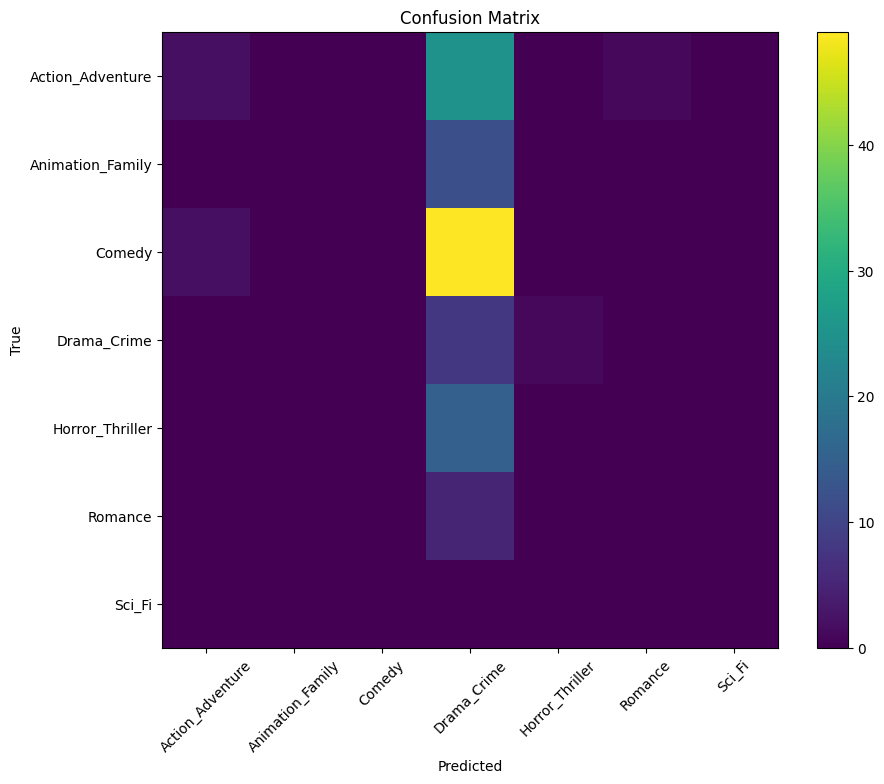

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

labels_range = list(range(len(class_names)))

print(classification_report(
    all_labels,
    all_preds,
    labels=labels_range,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=labels_range
)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
# Predict one image
def predict_image(image_path):
    checkpoint = torch.load("best_movie_genre_model.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    image = Image.open(image_path).convert("RGB")
    tensor = eval_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()

    return {
        "predicted_genre": class_names[pred_idx],
        "confidence": float(probs[pred_idx]),
        "all_probabilities": {
            class_names[i]: float(probs[i])
            for i in range(len(class_names))
        }
    }

# Example:
# predict_image("images/0.jpg")
